# 02 - Exploratory data analysis
Business questions first, charts second. Input: `order_base.csv` from notebook 01. Output: 38 PNG charts in `images/`, `restaurant_scorecard.csv`, `reports/kpis.json`.

**Definitions used everywhere** - Revenue: sum of `FinalAmount` over completed orders (Delivered + Delivered Late). Late: share of completed deliveries marked *Delivered Late*.

Engineered features (distance proxy, CLV, efficiency, ...) and the correlation analysis are in notebook 03.

In [1]:
import json, pathlib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", rc={"axes.titleweight": "bold"})
RED, DARK, GREY = "#E23744", "#2D2D2D", "#9C9C9C"

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
CLEAN, IMG, REP = ROOT / "data" / "cleaned", ROOT / "images", ROOT / "reports"
IMG.mkdir(exist_ok=True); REP.mkdir(exist_ok=True)
COUNT = {"mpl": 0, "sns": 0}
def save(fig, name, kind):
    """tight layout, write images/eda_<kind>_<name>.png, count it (figure stays open so Jupyter displays it)"""
    fig.tight_layout(); fig.savefig(IMG / f"eda_{kind}_{name}.png", dpi=120); COUNT[kind] += 1
def fig_ax(w=7, h=4.2): return plt.subplots(figsize=(w, h))

# order-level base table from notebook 01 + a few derived columns (the engineered features live in notebook 03)
b = pd.read_csv(CLEAN / "order_base.csv", parse_dates=["OrderDate", "RegistrationDate", "OrderTS"])
b["hour"], b["dow"] = b.OrderTS.dt.hour, b.OrderDate.dt.dayofweek
b["WeekendOrder"] = (b.dow >= 5).astype(int)
b["IsDelivered"] = b.OrderStatus.isin(["Delivered", "Delivered Late"])
b["IsCancelled"] = (b.OrderStatus == "Cancelled").astype(int); b["IsLate"] = (b.OrderStatus == "Delivered Late").astype(int)
b["HasCoupon"] = b.CouponCode.notna().astype(int); b["DiscountPct"] = np.where(b.FoodCost > 0, b.Discount / b.FoodCost, 0)
b["RainImpact"] = pd.cut(b.Rainfall, [-1, 0.5, 10, 50, np.inf], labels=[0, 1, 2, 3]).astype(int)
abt = b; dl = b[b.IsDelivered].copy(); dl["month"] = dl.OrderDate.dt.to_period("M").dt.to_timestamp()
promos = pd.read_csv(CLEAN / "promotions.csv"); rest = pd.read_csv(CLEAN / "restaurants.csv")
print(f"{len(abt):,} orders | {len(dl):,} completed (Delivered + Delivered Late)")
abt.OrderStatus.value_counts(normalize=True).mul(100).round(2)

20,475 orders | 13,544 completed (Delivered + Delivered Late)


OrderStatus
Delivered             55.63
Cancelled             22.32
Food Not Delivered    11.54
Delivered Late        10.52
Name: proportion, dtype: float64

## 1. Headline KPIs

In [2]:
# Revenue = sum of FinalAmount over COMPLETED orders. Cancelled / Food-Not-Delivered orders earn nothing.
# Late = share of completed deliveries with status "Delivered Late".
comp = dl
cust_orders = abt.groupby("CustomerID").OrderID.count()
headline = pd.Series({
    "Orders": len(abt), "Completed orders": len(comp), "Revenue (INR)": comp.FinalAmount.sum(), "Avg order value": comp.FinalAmount.mean(),
    "Cancelled %": abt.IsCancelled.mean() * 100, "Food-not-delivered %": (abt.OrderStatus == "Food Not Delivered").mean() * 100,
    "Late % of completed": comp.IsLate.mean() * 100, "Avg delivery (min)": comp.DeliveryTimeMinutes.mean(),
    "P90 delivery (min)": np.percentile(comp.DeliveryTimeMinutes.dropna(), 90), "One-time customers %": (cust_orders == 1).mean() * 100})
headline.round(2)

Orders                    20475.00
Completed orders          13544.00
Revenue (INR)           5308590.40
Avg order value             391.95
Cancelled %                  22.32
Food-not-delivered %         11.54
Late % of completed          15.90
Avg delivery (min)           38.35
P90 delivery (min)           60.00
One-time customers %         37.80
dtype: float64

## 2. Matplotlib charts (20)
Revenue, trend and mix.

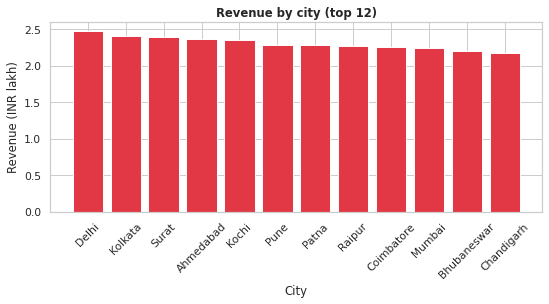

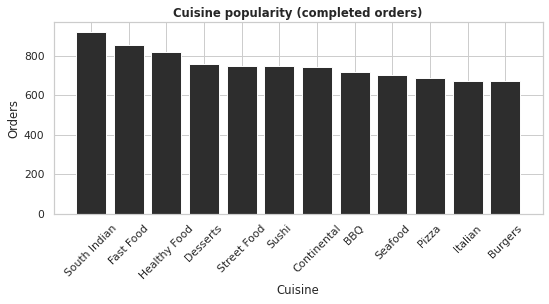

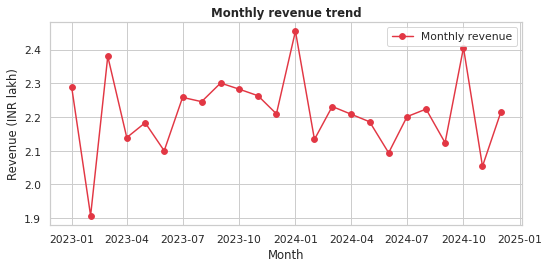

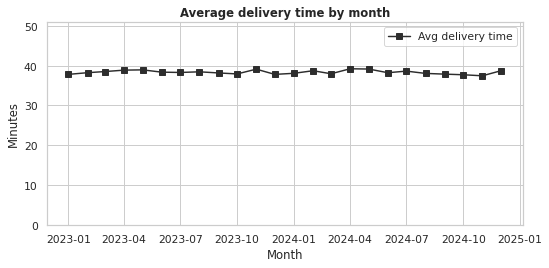

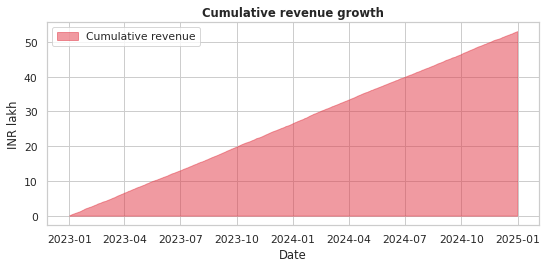

In [3]:
# ---------------- Matplotlib 1-5: where does revenue come from, and how is it trending? ----------------
s = dl.groupby("RCity").FinalAmount.sum().sort_values(ascending=False).head(12)
f, a = fig_ax(8, 4.5); a.bar(s.index, s.values / 1e5, color=RED); a.set(title="Revenue by city (top 12)", xlabel="City", ylabel="Revenue (INR lakh)"); a.tick_params(axis="x", rotation=45); save(f, "01_revenue_by_city", "mpl")
s = dl.groupby("Cuisine").OrderID.count().sort_values(ascending=False).head(12)
f, a = fig_ax(8, 4.5); a.bar(s.index, s.values, color=DARK); a.set(title="Cuisine popularity (completed orders)", xlabel="Cuisine", ylabel="Orders"); a.tick_params(axis="x", rotation=45); save(f, "02_cuisine_popularity", "mpl")
m = dl.groupby("month").FinalAmount.sum()
f, a = fig_ax(8, 4); a.plot(m.index, m.values / 1e5, marker="o", color=RED, label="Monthly revenue"); a.set(title="Monthly revenue trend", xlabel="Month", ylabel="Revenue (INR lakh)"); a.legend(); save(f, "03_monthly_revenue", "mpl")
m2 = dl.groupby("month").DeliveryTimeMinutes.mean()
f, a = fig_ax(8, 4); a.plot(m2.index, m2.values, marker="s", color=DARK, label="Avg delivery time"); a.set(title="Average delivery time by month", xlabel="Month", ylabel="Minutes", ylim=(0, m2.max() * 1.3)); a.legend(); save(f, "04_delivery_time_trend", "mpl")
cum = dl.groupby("OrderDate").FinalAmount.sum().cumsum() / 1e5
f, a = fig_ax(8, 4); a.fill_between(cum.index, cum.values, color=RED, alpha=.5, label="Cumulative revenue"); a.set(title="Cumulative revenue growth", xlabel="Date", ylabel="INR lakh"); a.legend(); save(f, "11_area_cumulative_revenue", "mpl")

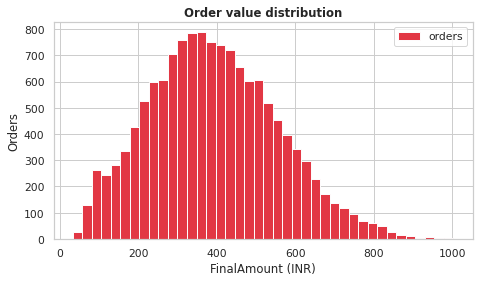

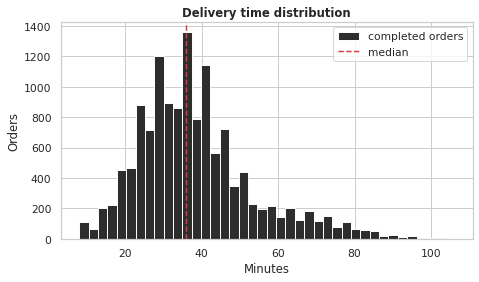

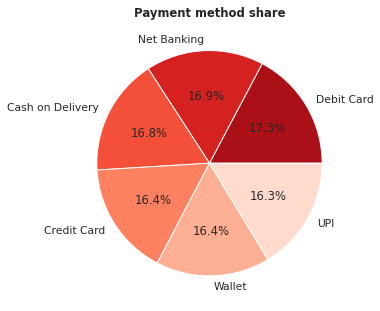

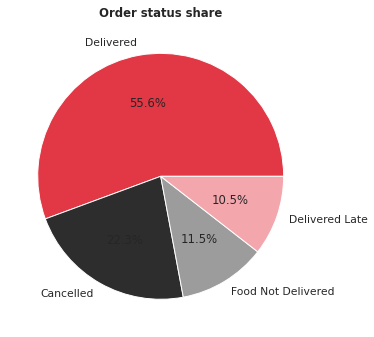

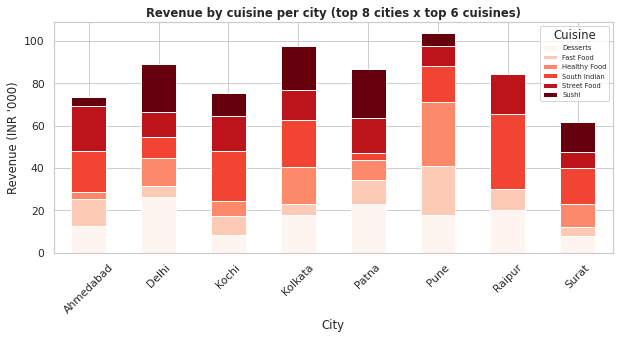

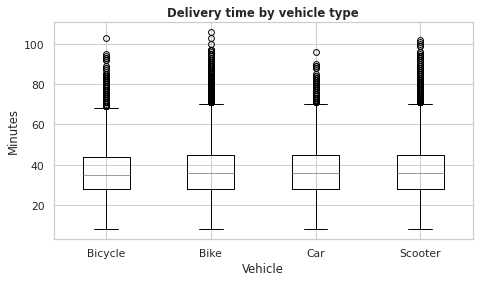

In [4]:
# ---------------- Matplotlib 6-12: distributions and mix ----------------
f, a = fig_ax(); a.hist(dl.FinalAmount, bins=40, color=RED, label="orders"); a.set(title="Order value distribution", xlabel="FinalAmount (INR)", ylabel="Orders"); a.legend(); save(f, "06_hist_order_value", "mpl")
f, a = fig_ax(); a.hist(dl.DeliveryTimeMinutes.dropna(), bins=40, color=DARK, label="completed orders"); a.axvline(dl.DeliveryTimeMinutes.median(), color=RED, ls="--", label="median"); a.set(title="Delivery time distribution", xlabel="Minutes", ylabel="Orders"); a.legend(); save(f, "07_hist_delivery_time", "mpl")
pm = abt.PaymentMethod.value_counts(); f, a = fig_ax(5.5, 5.5); a.pie(pm, labels=pm.index, autopct="%1.1f%%", colors=sns.color_palette("Reds_r", len(pm))); a.set_title("Payment method share"); save(f, "08_pie_payment_method", "mpl")
st = abt.OrderStatus.value_counts(); f, a = fig_ax(5.5, 5.5); a.pie(st, labels=st.index, autopct="%1.1f%%", colors=[RED, DARK, GREY, "#F4A6AD"]); a.set_title("Order status share"); save(f, "09_pie_order_status", "mpl")
top_c = dl.groupby("RCity").FinalAmount.sum().nlargest(8).index; top_q = dl.Cuisine.value_counts().head(6).index
pv = dl[dl.RCity.isin(top_c) & dl.Cuisine.isin(top_q)].pivot_table(index="RCity", columns="Cuisine", values="FinalAmount", aggfunc="sum", fill_value=0) / 1e3
f, a = fig_ax(9, 5); pv.plot(kind="bar", stacked=True, ax=a, colormap="Reds"); a.set(title="Revenue by cuisine per city (top 8 cities x top 6 cuisines)", xlabel="City", ylabel="Revenue (INR '000)"); a.legend(title="Cuisine", fontsize=7); a.tick_params(axis="x", rotation=45); save(f, "10_stacked_revenue_cuisine_city", "mpl")
vt = [g.DeliveryTimeMinutes.dropna().values for _, g in dl.groupby("VehicleType")]
f, a = fig_ax(); a.boxplot(vt, labels=sorted(dl.VehicleType.unique())); a.set(title="Delivery time by vehicle type", xlabel="Vehicle", ylabel="Minutes"); save(f, "12_box_time_by_vehicle", "mpl")

matplotlib charts so far: 19


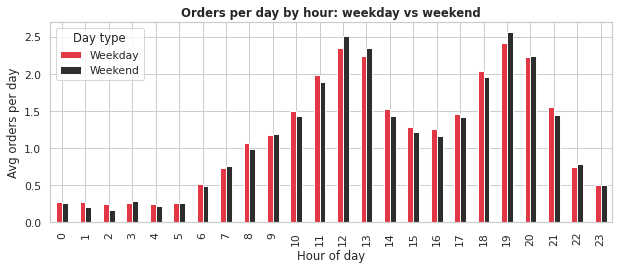

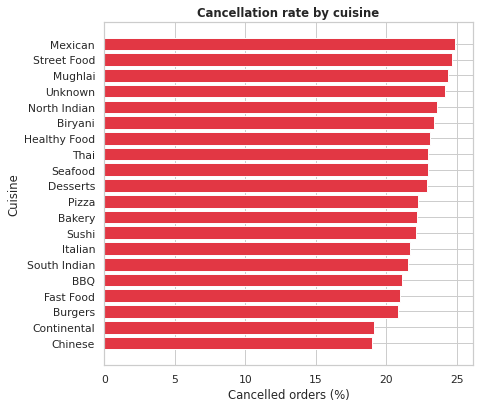

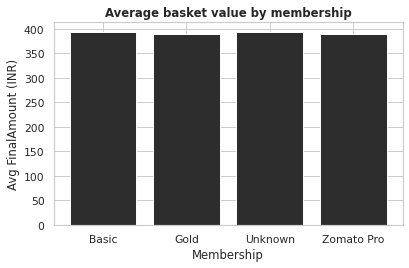

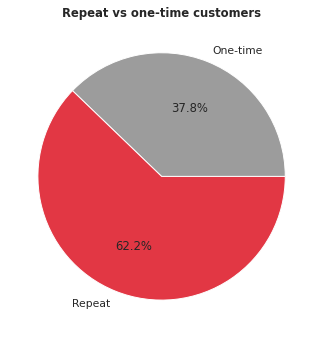

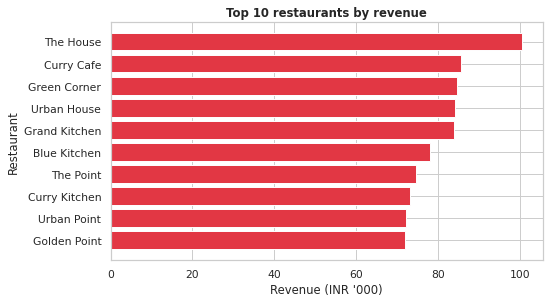

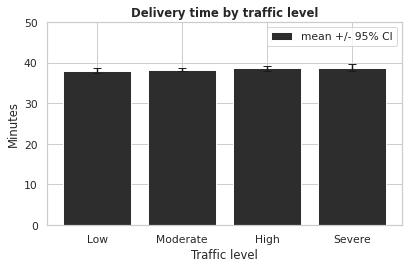

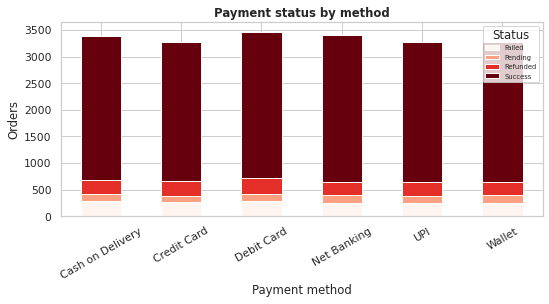

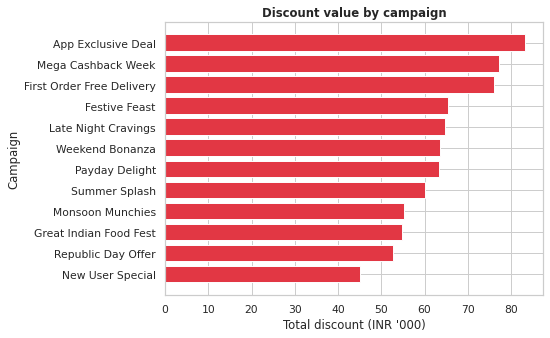

In [5]:
# ---------------- Matplotlib 13-20: behaviour, cancellations, restaurants, payments ----------------
hw = abt.assign(wk=np.where(abt.WeekendOrder == 1, "Weekend", "Weekday")).groupby(["hour", "wk"]).OrderID.count().unstack()
hw = hw.div(abt.groupby(np.where(abt.WeekendOrder == 1, "Weekend", "Weekday")).OrderDate.nunique())      # per-day average
f, a = fig_ax(9, 4); hw.plot(kind="bar", ax=a, color=[RED, DARK]); a.set(title="Orders per day by hour: weekday vs weekend", xlabel="Hour of day", ylabel="Avg orders per day"); a.legend(title="Day type"); save(f, "13_orders_by_hour", "mpl")
cr = abt.groupby("Cuisine").IsCancelled.mean().sort_values() * 100
f, a = fig_ax(7, 6); a.barh(cr.index, cr.values, color=RED); a.set(title="Cancellation rate by cuisine", xlabel="Cancelled orders (%)", ylabel="Cuisine"); save(f, "14_cancellation_by_cuisine", "mpl")
mb = dl.groupby("Membership").FinalAmount.mean()
f, a = fig_ax(6, 4); a.bar(mb.index, mb.values, color=DARK); a.set(title="Average basket value by membership", xlabel="Membership", ylabel="Avg FinalAmount (INR)"); save(f, "15_basket_by_membership", "mpl")
oc = abt.groupby("CustomerID").size(); rep = pd.Series({"One-time": (oc == 1).sum(), "Repeat": (oc > 1).sum()})
f, a = fig_ax(5, 5); a.pie(rep, labels=rep.index, autopct="%1.1f%%", colors=[GREY, RED]); a.set_title("Repeat vs one-time customers"); save(f, "16_pie_repeat_customers", "mpl")
tr = dl.groupby("RestaurantName").FinalAmount.sum().nlargest(10).iloc[::-1]
f, a = fig_ax(8, 4.5); a.barh(tr.index, tr.values / 1e3, color=RED); a.set(title="Top 10 restaurants by revenue", xlabel="Revenue (INR '000)", ylabel="Restaurant"); save(f, "17_top_restaurants", "mpl")
tl = dl.groupby("TrafficScore").DeliveryTimeMinutes.agg(["mean", "sem"])
f, a = fig_ax(6, 4); a.bar(["Low", "Moderate", "High", "Severe"][:len(tl)], tl["mean"], yerr=1.96 * tl["sem"], color=DARK, capsize=4, label="mean +/- 95% CI"); a.set(title="Delivery time by traffic level", xlabel="Traffic level", ylabel="Minutes", ylim=(0, 50)); a.legend(); save(f, "18_time_by_traffic", "mpl")
ps = abt.groupby(["PaymentMethod", "PaymentStatus"]).size().unstack(fill_value=0)
f, a = fig_ax(8, 4.5); ps.plot(kind="bar", stacked=True, ax=a, colormap="Reds"); a.set(title="Payment status by method", xlabel="Payment method", ylabel="Orders"); a.legend(title="Status", fontsize=7); a.tick_params(axis="x", rotation=30); save(f, "19_payment_status", "mpl")
cp = abt[abt.HasCoupon == 1].merge(promos[["CouponCode", "CampaignName"]], on="CouponCode").groupby("CampaignName").Discount.sum().sort_values()
f, a = fig_ax(8, 5); a.barh(cp.index, cp.values / 1e3, color=RED); a.set(title="Discount value by campaign", xlabel="Total discount (INR '000)", ylabel="Campaign"); save(f, "20_discount_by_campaign", "mpl")
print("matplotlib charts so far:", COUNT["mpl"])

## 3. Seaborn charts (14 here, 4 more in notebook 03)

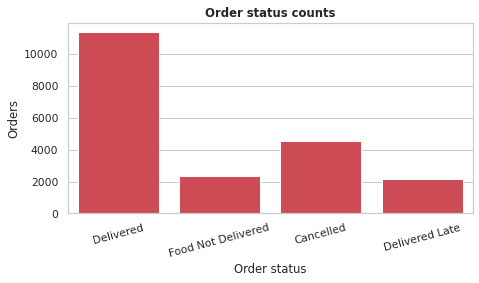

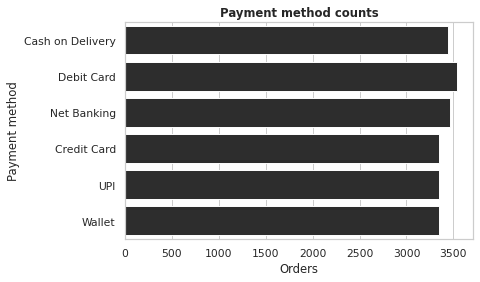

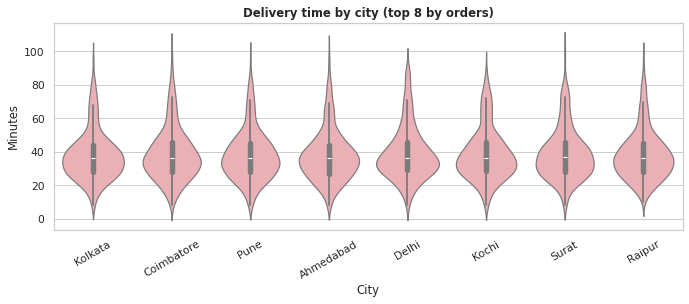

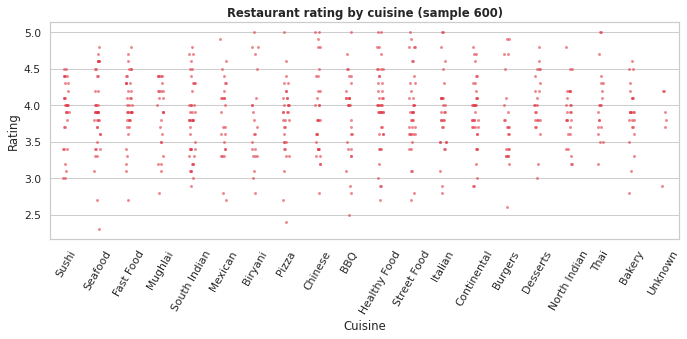

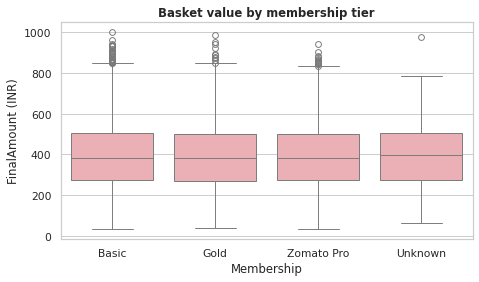

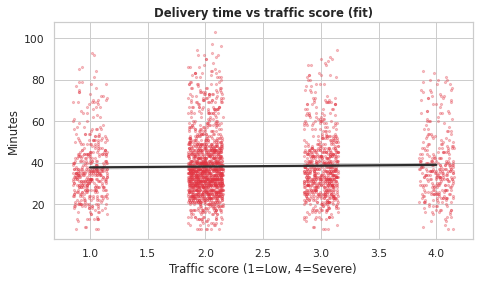

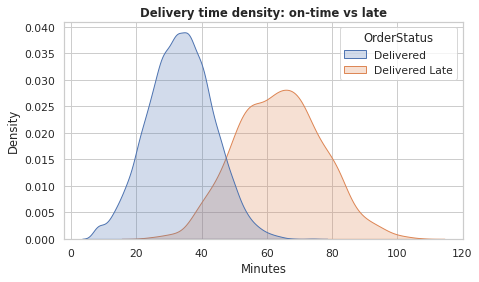

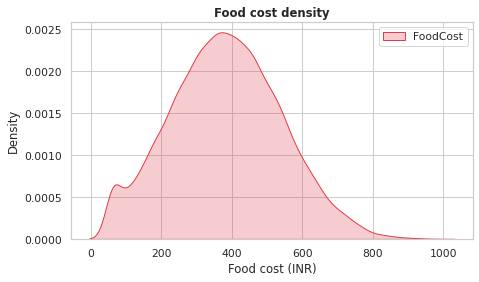

In [6]:
# ---------------- Seaborn 1: distribution / category views ----------------
f, a = fig_ax(); sns.countplot(data=abt, x="OrderStatus", color=RED, ax=a); a.set(title="Order status counts", xlabel="Order status", ylabel="Orders"); a.tick_params(axis="x", rotation=15); save(f, "03_count_order_status", "sns")
f, a = fig_ax(); sns.countplot(data=abt, y="PaymentMethod", color=DARK, ax=a); a.set(title="Payment method counts", xlabel="Orders", ylabel="Payment method"); save(f, "04_count_payment_method", "sns")
t8 = dl.RCity.value_counts().head(8).index
f, a = fig_ax(10, 4.5); sns.violinplot(data=dl[dl.RCity.isin(t8)], x="RCity", y="DeliveryTimeMinutes", color="#F4A6AD", ax=a); a.set(title="Delivery time by city (top 8 by orders)", xlabel="City", ylabel="Minutes"); a.tick_params(axis="x", rotation=30); save(f, "05_violin_time_by_city", "sns")
rs = rest.sample(600, random_state=1)
f, a = fig_ax(10, 5); sns.stripplot(data=rs, x="Cuisine", y="Rating", size=3, color=RED, alpha=.6, ax=a); a.set(title="Restaurant rating by cuisine (sample 600)", xlabel="Cuisine", ylabel="Rating"); a.tick_params(axis="x", rotation=60); save(f, "06_strip_rating_by_cuisine", "sns")
f, a = fig_ax(); sns.boxplot(data=dl, x="Membership", y="FinalAmount", color="#F4A6AD", ax=a); a.set(title="Basket value by membership tier", xlabel="Membership", ylabel="FinalAmount (INR)"); save(f, "07_box_basket_membership", "sns")
sm = dl.dropna(subset=["DeliveryTimeMinutes"]).sample(3000, random_state=2)
f, a = fig_ax(); sns.regplot(data=sm, x="TrafficScore", y="DeliveryTimeMinutes", x_jitter=.15, scatter_kws=dict(s=5, alpha=.3, color=RED), line_kws=dict(color=DARK), ax=a); a.set(title="Delivery time vs traffic score (fit)", xlabel="Traffic score (1=Low, 4=Severe)", ylabel="Minutes"); save(f, "09_reg_time_vs_traffic", "sns")
f, a = fig_ax(); sns.kdeplot(data=dl.dropna(subset=["DeliveryTimeMinutes"]), x="DeliveryTimeMinutes", hue="OrderStatus", fill=True, common_norm=False, ax=a); a.set(title="Delivery time density: on-time vs late", xlabel="Minutes", ylabel="Density"); save(f, "10_kde_delivery_time", "sns")
f, a = fig_ax(); sns.kdeplot(data=abt, x="FoodCost", fill=True, color=RED, label="FoodCost", ax=a); a.set(title="Food cost density", xlabel="Food cost (INR)", ylabel="Density"); a.legend(); save(f, "11_kde_food_cost", "sns")

charts in this notebook: {'mpl': 19, 'sns': 15}


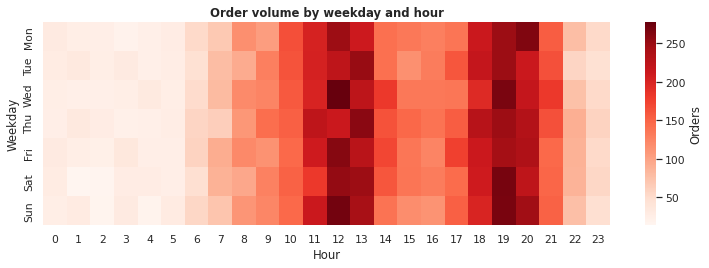

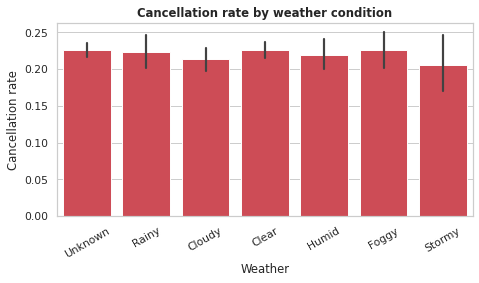

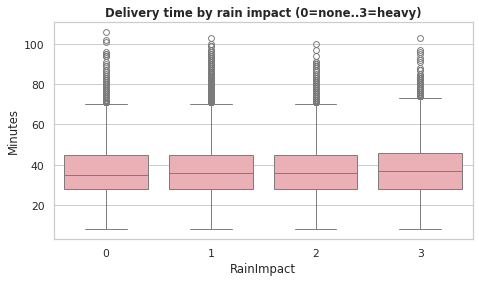

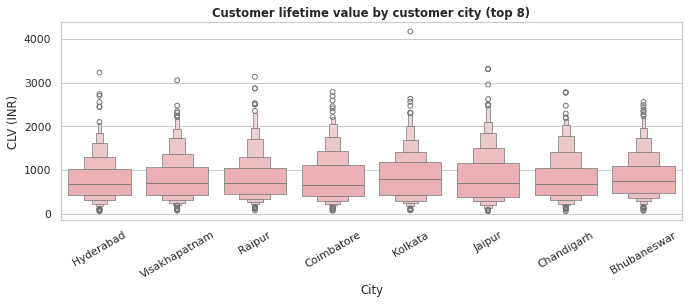

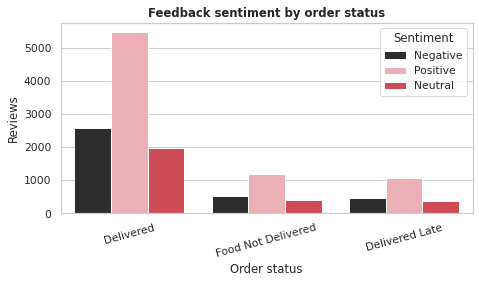

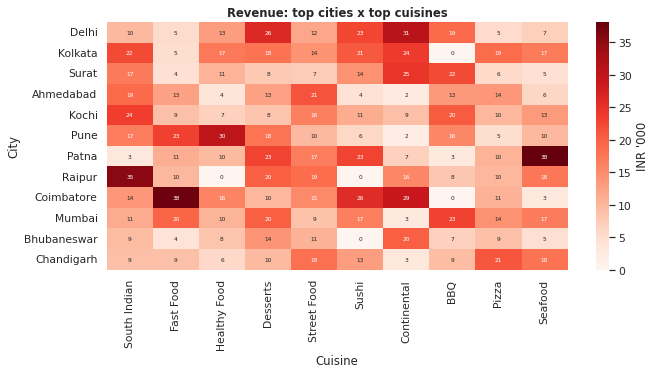

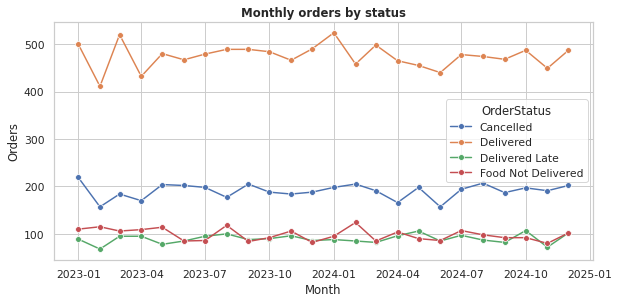

In [7]:
# ---------------- Seaborn 2: weather, time-of-day, customers, sentiment ----------------
hm = abt.groupby(["dow", "hour"]).size().unstack(fill_value=0); hm.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
f, a = fig_ax(11, 4); sns.heatmap(hm, cmap="Reds", ax=a, cbar_kws={"label": "Orders"}); a.set(title="Order volume by weekday and hour", xlabel="Hour", ylabel="Weekday"); save(f, "12_heatmap_hour_dow", "sns")
f, a = fig_ax(); sns.barplot(data=abt, x="WeatherCondition", y="IsCancelled", color=RED, ax=a, errorbar=("ci", 95)); a.set(title="Cancellation rate by weather condition", xlabel="Weather", ylabel="Cancellation rate"); a.tick_params(axis="x", rotation=30); save(f, "13_bar_cancel_by_weather", "sns")
f, a = fig_ax(); sns.boxplot(data=dl, x="RainImpact", y="DeliveryTimeMinutes", color="#F4A6AD", ax=a); a.set(title="Delivery time by rain impact (0=none..3=heavy)", xlabel="RainImpact", ylabel="Minutes"); save(f, "14_box_time_by_rain", "sns")
clv = abt.groupby("CustomerID").agg(CLV=("FinalAmount", "sum"), City=("CCity", "first")); top_cc = clv.City.value_counts().head(8).index
f, a = fig_ax(10, 4.5); sns.boxenplot(data=clv[clv.City.isin(top_cc)], x="City", y="CLV", color="#F4A6AD", ax=a); a.set(title="Customer lifetime value by customer city (top 8)", xlabel="City", ylabel="CLV (INR)"); a.tick_params(axis="x", rotation=30); save(f, "15_boxen_clv_by_city", "sns")
fb = abt.dropna(subset=["Sentiment"])
f, a = fig_ax(); sns.countplot(data=fb, x="OrderStatus", hue="Sentiment", palette=["#2D2D2D", "#F4A6AD", RED], ax=a); a.set(title="Feedback sentiment by order status", xlabel="Order status", ylabel="Reviews"); a.tick_params(axis="x", rotation=15); save(f, "16_count_sentiment_by_status", "sns")
hc = dl.pivot_table(index="RCity", columns="Cuisine", values="FinalAmount", aggfunc="sum", fill_value=0).loc[lambda x: x.sum(1).nlargest(12).index, lambda x: x.sum().nlargest(10).index] / 1e3
f, a = fig_ax(10, 5.5); sns.heatmap(hc, cmap="Reds", annot=True, fmt=".0f", annot_kws={"size": 6}, ax=a, cbar_kws={"label": "INR '000"}); a.set(title="Revenue: top cities x top cuisines", xlabel="Cuisine", ylabel="City"); save(f, "17_heatmap_city_cuisine", "sns")
ms = abt.assign(month=abt.OrderDate.dt.to_period("M").dt.to_timestamp()).groupby(["month", "OrderStatus"]).size().reset_index(name="orders")
f, a = fig_ax(9, 4.5); sns.lineplot(data=ms, x="month", y="orders", hue="OrderStatus", marker="o", ax=a); a.set(title="Monthly orders by status", xlabel="Month", ylabel="Orders"); save(f, "18_line_orders_by_status", "sns")
print("charts in this notebook:", COUNT)

## 4. Restaurant scorecard
A composite avoids ranking restaurants on rating alone; the weights (0.4/0.3/0.3) are a judgement call - state it and test sensitivity if you present it.

In [8]:
# ---- Restaurant scorecard: composite = 0.4*z(rating) - 0.3*z(cancel rate) - 0.3*z(late rate); restaurants with >= 5 orders ----
g = abt.groupby(["RestaurantID", "RestaurantName", "RCity", "Cuisine"]).agg(
    Orders=("OrderID", "count"), Revenue=("FinalAmount", lambda s: s[abt.loc[s.index, "IsDelivered"]].sum()),
    Rating=("RestaurantRating", "first"), CancelRate=("IsCancelled", "mean"),
    LateRate=("IsLate", lambda s: s.sum() / max(abt.loc[s.index, "IsDelivered"].sum(), 1)), AvgDeliveryTime=("DeliveryTimeMinutes", "mean")).reset_index()
sc = g[g.Orders >= 5].copy(); z = lambda s: (s - s.mean()) / s.std()
sc["CompositeScore"] = 0.4 * z(sc.Rating) - 0.3 * z(sc.CancelRate) - 0.3 * z(sc.LateRate)
sc["CityRank"] = sc.groupby("RCity")["CompositeScore"].rank(ascending=False, method="first")
sc["CityRankFromBottom"] = sc.groupby("RCity")["CompositeScore"].rank(ascending=True, method="first")
sc = sc.sort_values("CompositeScore", ascending=False)
sc.to_csv(CLEAN / "restaurant_scorecard.csv", index=False)
sc[sc.CityRank <= 10].to_csv(CLEAN / "restaurants_top10_per_city.csv", index=False); sc[sc.CityRankFromBottom <= 10].to_csv(CLEAN / "restaurants_bottom10_per_city.csv", index=False)
print(len(sc), "restaurants scored"); sc.head(8).round(3)

1200 restaurants scored


,RestaurantID,RestaurantName,RCity,Cuisine,Orders,Revenue,Rating,CancelRate,LateRate,AvgDeliveryTime,CompositeScore,CityRank,CityRankFromBottom
909,910,Royal Bites,Mumbai,Burgers,14,4743.15,4.5,0.000,0.000,33.929,1.550,1.0,51.0
604,605,Spicy Bites,Bhopal,Burgers,17,4160.45,4.7,0.059,0.000,31.882,1.543,1.0,51.0
1100,1101,Green Diner,Bhopal,Thai,14,3906.60,5.0,0.071,0.083,36.769,1.535,2.0,50.0
1091,1092,Golden Point,Coimbatore,Fast Food,21,6481.15,4.8,0.048,0.062,36.524,1.495,1.0,47.0
328,329,Green Kitchen,Lucknow,Continental,18,4794.40,5.0,0.167,0.000,36.389,1.475,1.0,46.0
375,376,Golden House,Nashik,Chinese,17,4697.95,5.0,0.176,0.000,32.235,1.447,1.0,42.0
343,344,The Cafe,Kolkata,Pizza,13,2310.70,4.6,0.077,0.000,37.000,1.410,1.0,51.0
445,446,Tasty Diner,Kolkata,Healthy Food,15,3198.95,5.0,0.200,0.000,34.933,1.379,2.0,50.0


## 5. Do traffic and rain slow deliveries?
A z-test on the mean difference. |z| < 1.96 means the gap is within what chance produces.

In [9]:
# ---- Business questions answered with numbers (these feed kpis.json -> reports, deck, Power BI) ----
a, b2 = comp[comp.TrafficScore >= 3].DeliveryTimeMinutes.dropna(), comp[comp.TrafficScore <= 2].DeliveryTimeMinutes.dropna()
z_traffic = (a.mean() - b2.mean()) / np.sqrt(a.var() / len(a) + b2.var() / len(b2)); d_traffic = a.mean() - b2.mean()
a, b2 = comp[comp.RainImpact >= 2].DeliveryTimeMinutes.dropna(), comp[comp.RainImpact <= 1].DeliveryTimeMinutes.dropna()
z_rain = (a.mean() - b2.mean()) / np.sqrt(a.var() / len(a) + b2.var() / len(b2)); d_rain = a.mean() - b2.mean()
print(f"High/Severe vs Low/Moderate traffic: {d_traffic:+.2f} min (z={z_traffic:.2f})")
print(f"Heavy vs light rain:                 {d_rain:+.2f} min (z={z_rain:.2f})   |z|<1.96 -> not significant at 5%")
pd.DataFrame({"mean delivery min by traffic (1=Low..4=Severe)": comp.groupby("TrafficScore").DeliveryTimeMinutes.mean(),
              "late % by traffic": comp.groupby("TrafficScore").IsLate.mean() * 100}).round(2)

High/Severe vs Low/Moderate traffic: +0.37 min (z=1.36)
Heavy vs light rain:                 +0.14 min (z=0.47)   |z|<1.96 -> not significant at 5%


,mean delivery min by traffic (1=Low..4=Severe),late % by traffic
TrafficScore,,
1.0,37.99,15.96
2.0,38.28,15.34
3.0,38.53,16.75
4.0,38.72,16.46


## 6. Save KPIs for the reports and Power BI

In [10]:
kpi = dict(
    orders_total=int(len(abt)), customers_with_orders=int(abt.CustomerID.nunique()), restaurants_with_orders=int(abt.RestaurantID.nunique()),
    revenue_inr=float(comp.FinalAmount.sum()), avg_order_value=float(comp.FinalAmount.mean()), completed_orders=int(len(comp)),
    cancelled_pct=float(abt.IsCancelled.mean() * 100), food_not_delivered_pct=float((abt.OrderStatus == "Food Not Delivered").mean() * 100),
    late_pct_of_completed=float(comp.IsLate.mean() * 100), avg_delivery_min=float(comp.DeliveryTimeMinutes.mean()), median_delivery_min=float(comp.DeliveryTimeMinutes.median()),
    p90_delivery_min=float(np.percentile(comp.DeliveryTimeMinutes.dropna(), 90)), p95_delivery_min=float(np.percentile(comp.DeliveryTimeMinutes.dropna(), 95)),
    avg_feedback_rating=float(abt.AvgRating.mean()), one_time_customers_pct=float((cust_orders == 1).mean() * 100),
    top_city=str(comp.groupby("RCity").FinalAmount.sum().idxmax()), top_cuisine=str(comp.groupby("Cuisine").FinalAmount.sum().idxmax()),
    peak_hour=int(abt.groupby("hour").size().idxmax()), weekend_orders_pct=float(abt.WeekendOrder.mean() * 100),
    avg_basket_by_membership=comp.groupby("Membership").FinalAmount.mean().round(1).to_dict(),
    delivery_time_by_traffic=comp.groupby("TrafficScore").DeliveryTimeMinutes.mean().round(2).to_dict(),
    delivery_time_by_rain=comp.groupby("RainImpact").DeliveryTimeMinutes.mean().round(2).to_dict(),
    late_pct_by_traffic=(comp.groupby("TrafficScore").IsLate.mean() * 100).round(2).to_dict(),
    cancel_pct_by_weather=(abt.groupby("WeatherCondition").IsCancelled.mean() * 100).round(2).to_dict(),
    cancel_pct_by_payment=(abt.groupby("PaymentMethod").IsCancelled.mean() * 100).round(2).to_dict(),
    cancel_pct_by_cuisine=(abt.groupby("Cuisine").IsCancelled.mean() * 100).round(2).sort_values().to_dict(),
    weather_join_rate=float(abt.HasWeather.mean()), traffic_join_rate=float(abt.HasTraffic.mean()),
    revenue_by_city=comp.groupby("RCity").FinalAmount.sum().round(0).sort_values(ascending=False).head(5).to_dict(),
    revenue_by_cuisine=comp.groupby("Cuisine").FinalAmount.sum().round(0).sort_values(ascending=False).head(5).to_dict(),
    coupon_usage_pct=float(abt.HasCoupon.mean() * 100), avg_discount_pct_when_coupon=float(abt.loc[abt.HasCoupon == 1, "DiscountPct"].mean() * 100),
    payment_failed_pct=float((abt.PaymentStatus == "Failed").mean() * 100),
    cancel_rate_late_vs_traffic_corr=float(abt[["IsCancelled", "TrafficScore"]].corr().iloc[0, 1]),
    traffic_high_vs_low_diff_min=float(d_traffic), traffic_high_vs_low_z=float(z_traffic), rain_heavy_vs_light_diff_min=float(d_rain), rain_heavy_vs_light_z=float(z_rain),
    mpl_charts=COUNT["mpl"], sns_charts=COUNT["sns"])        # notebook 03 adds its 4 feature-diagnostic Seaborn/Matplotlib charts
json.dump(kpi, open(REP / "kpis.json", "w"), indent=2, default=str)
print("saved reports/kpis.json"); {k: v for k, v in kpi.items() if not isinstance(v, dict)}

saved reports/kpis.json


{'orders_total': 20475, 'customers_with_orders': 9827, 'restaurants_with_orders': 1200, 'revenue_inr': 5308590.4, 'avg_order_value': 391.95144713526287, 'completed_orders': 13544, 'cancelled_pct': 22.315018315018314, 'food_not_delivered_pct': 11.536019536019536, 'late_pct_of_completed': 15.903721204961608, 'avg_delivery_min': 38.34812337421033, 'median_delivery_min': 36.0, 'p90_delivery_min': 60.0, 'p95_delivery_min': 70.0, 'avg_feedback_rating': 3.5141841450408817, 'one_time_customers_pct': 37.804009361961946, 'top_city': 'Delhi', 'top_cuisine': 'South Indian', 'peak_hour': 19, 'weekend_orders_pct': 28.3028083028083, 'weather_join_rate': 0.6301831501831502, 'traffic_join_rate': 0.6362881562881563, 'coupon_usage_pct': 35.1990231990232, 'avg_discount_pct_when_coupon': 27.668239211877342, 'payment_failed_pct': 7.858363858363858, 'cancel_rate_late_vs_traffic_corr': -0.004263089348214858, 'traffic_high_vs_low_diff_min': 0.3725317264211583, 'traffic_high_vs_low_z': 1.3570766840508028, 'rain

## 7. Summary of findings

In [11]:
# ---- Findings you should be able to defend in the viva (check each against the outputs above) ----
f = [("Revenue concentrates in", f"{comp.groupby('RCity').FinalAmount.sum().idxmax()} / {comp.groupby('Cuisine').FinalAmount.sum().idxmax()}"),
     ("Share of orders that never earn revenue", f"{(1 - len(comp) / len(abt)):.1%} (cancelled + food-not-delivered)"),
     ("Delivery time vs traffic", f"{d_traffic:+.2f} min between High/Severe and Low/Moderate (z={z_traffic:.2f})"),
     ("Delivery time vs rain", f"{d_rain:+.2f} min between heavy and light (z={z_rain:.2f})"),
     ("Repeat customers", f"{(cust_orders > 1).mean():.1%} order more than once")]
pd.DataFrame(f, columns=["finding", "evidence"])

,finding,evidence
0,Revenue concentrates in,Delhi / South Indian
1,Share of orders that never earn revenue,33.9% (cancelled + food-not-delivered)
2,Delivery time vs traffic,+0.37 min between High/Severe and Low/Moderate (z=1.36)
3,Delivery time vs rain,+0.14 min between heavy and light (z=0.47)
4,Repeat customers,62.2% order more than once


**Caution:** these are descriptive. A chart showing two things move together is not evidence of cause, and several relationships the PRD expects (traffic -> slower delivery, rain -> cancellations) are weak or absent in this data - see notebook 04 for the formal test.